# 🏨 Hotel Booking Demand - Exploratory Data Analysis

## Project Overview
This notebook explores the Hotel Booking Demand dataset to uncover patterns 
in hotel cancellations, customer behavior, and revenue trends.

## Key Questions We'll Answer
1. What is the overall cancellation rate, and how does it differ between hotel types?
2. Which months are the busiest? Is there seasonality?
3. Where do most customers come from?
4. What factors most strongly predict cancellations?
5. How do lead times affect cancellations?

## Dataset
- **Source**: Kaggle - Hotel Booking Demand
- **Records**: ~119,000 bookings
- **Period**: July 2015 to August 2017
- **Hotels**: City Hotel and Resort Hotel

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import warnings
import os

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (12, 6)  
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully!
Pandas version: 3.0.3
NumPy version: 2.5.1


In [5]:
DATA_PATH= os.path.join('..', 'data', 'raw', 'hotel_bookings.csv')
df= pd.read_csv(DATA_PATH)

print(f"✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully!
Shape: 119,390 rows × 32 columns



## 🔍 Section 1: Initial Data Exploration

Before cleaning anything, we look at the data in its raw form.
This helps us understand what we're working with and identify problems.

In [6]:
# Look at the first 5 rows
print("=" * 60)
print("FIRST 5 ROWS OF RAW DATA")
print("=" * 60)
df.head()

FIRST 5 ROWS OF RAW DATA


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [7]:
# This is your most important first step
# It shows you: column names, data types, and non-null counts
print("=" * 60)
print("DATA INFORMATION")
print("=" * 60)
df.info()

DATA INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal      

In [8]:
# Statistical summary of numerical columns
print("=" * 60)
print("STATISTICAL SUMMARY - NUMERICAL COLUMNS")
print("=" * 60)
df.describe().round(2)

STATISTICAL SUMMARY - NUMERICAL COLUMNS


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.1,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.4,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


In [9]:
# ============================================================
# FINDING MISSING VALUES - The Detective Work
# ============================================================

# Count missing values per column
missing_values = df.isnull().sum()

# Calculate percentage
missing_percent = (missing_values / len(df)) * 100

# Combine into a clean dataframe
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent.round(2)
})

# Only show columns that actually have missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df = missing_df.sort_values('Missing Percentage', ascending=False)

print("=" * 60)
print("COLUMNS WITH MISSING VALUES")
print("=" * 60)
print(missing_df)
print(f"\nTotal columns with missing data: {len(missing_df)}")

COLUMNS WITH MISSING VALUES
          Missing Count  Missing Percentage
company          112593               94.31
agent             16340               13.69
country             488                0.41
children              4                0.00

Total columns with missing data: 4


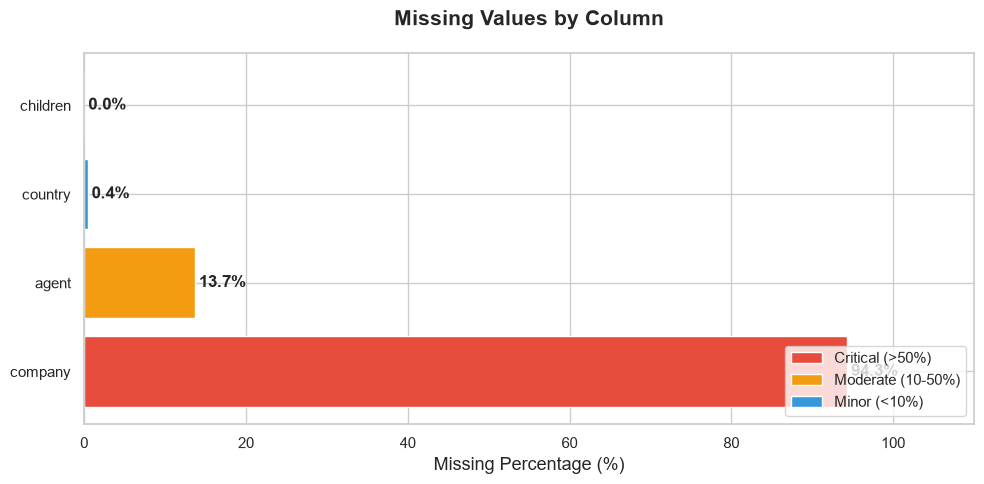

✅ Figure saved!


In [10]:
# Visualize missing values - much easier to understand than numbers
fig, ax = plt.subplots(figsize=(10, 5))

# Only plot if there are missing values
if len(missing_df) > 0:
    colors = ['#e74c3c' if x > 50 else '#f39c12' if x > 10 else '#3498db' 
              for x in missing_df['Missing Percentage']]
    
    bars = ax.barh(missing_df.index, missing_df['Missing Percentage'], color=colors)
    
    # Add value labels on bars
    for bar, val in zip(bars, missing_df['Missing Percentage']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontweight='bold')
    
    ax.set_xlabel('Missing Percentage (%)', fontsize=13)
    ax.set_title('Missing Values by Column', fontsize=15, fontweight='bold', pad=20)
    ax.set_xlim(0, 110)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#e74c3c', label='Critical (>50%)'),
                       Patch(facecolor='#f39c12', label='Moderate (10-50%)'),
                       Patch(facecolor='#3498db', label='Minor (<10%)')]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    
    # Save the figure
    plt.savefig('../reports/figures/01_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Figure saved!")
else:
    print("No missing values found!")

In [11]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count:,}")
print(f"Percentage of duplicates: {(duplicate_count/len(df)*100):.2f}%")

# Also check unique values in key categorical columns
print("\n" + "=" * 60)
print("UNIQUE VALUES IN KEY CATEGORICAL COLUMNS")
print("=" * 60)

categorical_cols = ['hotel', 'arrival_date_month', 'meal', 
                    'market_segment', 'distribution_channel', 
                    'customer_type', 'reservation_status']

for col in categorical_cols:
    if col in df.columns:
        unique_vals = df[col].unique()
        print(f"\n{col} ({len(unique_vals)} unique values):")
        print(f"  {sorted(unique_vals)}")

Number of duplicate rows: 31,994
Percentage of duplicates: 26.80%

UNIQUE VALUES IN KEY CATEGORICAL COLUMNS

hotel (2 unique values):
  ['City Hotel', 'Resort Hotel']

arrival_date_month (12 unique values):
  ['April', 'August', 'December', 'February', 'January', 'July', 'June', 'March', 'May', 'November', 'October', 'September']

meal (5 unique values):
  ['BB', 'FB', 'HB', 'SC', 'Undefined']

market_segment (8 unique values):
  ['Aviation', 'Complementary', 'Corporate', 'Direct', 'Groups', 'Offline TA/TO', 'Online TA', 'Undefined']

distribution_channel (5 unique values):
  ['Corporate', 'Direct', 'GDS', 'TA/TO', 'Undefined']

customer_type (4 unique values):
  ['Contract', 'Group', 'Transient', 'Transient-Party']

reservation_status (3 unique values):
  ['Canceled', 'Check-Out', 'No-Show']



## 🧹 Section 2: Data Cleaning

Now we fix all the problems we found. We create a COPY of the data
and never modify the original. This is professional best practice.

**Problems to fix:**
1. `company` column is 94% missing - we'll drop it
2. `agent` column is 14% missing - we'll fill with 0 (no agent)
3. `country` is 0.4% missing - we'll fill with 'Unknown'  
4. `children` has 4 missing values - we'll fill with 0
5. `meal` has inconsistent value 'Undefined' - we'll fix it
6. Need to create a proper date column from separate year/month/day columns

In [12]:
# ============================================================
# DATA CLEANING - Always work on a COPY
# ============================================================

# Create a copy - NEVER modify original df
df_clean = df.copy()

print("Starting data cleaning...")
print(f"Original shape: {df_clean.shape}")
print("-" * 40)

# ---- STEP 1: Drop 'company' column (94% missing, not useful) ----
df_clean = df_clean.drop(columns=['company'])
print("✅ Step 1: Dropped 'company' column (94% missing)")

# ---- STEP 2: Handle 'agent' - fill missing with 0 (means no agent) ----
df_clean['agent'] = df_clean['agent'].fillna(0).astype(int)
print(f"✅ Step 2: Filled {df['agent'].isnull().sum()} missing 'agent' values with 0")

# ---- STEP 3: Handle 'country' - fill with 'Unknown' ----
df_clean['country'] = df_clean['country'].fillna('Unknown')
print(f"✅ Step 3: Filled {df['country'].isnull().sum()} missing 'country' values with 'Unknown'")

# ---- STEP 4: Handle 'children' - fill with 0 ----
df_clean['children'] = df_clean['children'].fillna(0).astype(int)
print(f"✅ Step 4: Filled {df['children'].isnull().sum()} missing 'children' values with 0")

# ---- STEP 5: Fix 'meal' - 'Undefined' means no meal package (SC) ----
df_clean['meal'] = df_clean['meal'].replace('Undefined', 'SC')
print("✅ Step 5: Replaced 'Undefined' meal type with 'SC' (No meal)")

# ---- STEP 6: Remove duplicate rows ----
before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates()
after_dedup = len(df_clean)
print(f"✅ Step 6: Removed {before_dedup - after_dedup} duplicate rows")

# ---- STEP 7: Create proper date column ----
# Month names to numbers mapping
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

df_clean['arrival_date_month_num'] = df_clean['arrival_date_month'].map(month_map)

# Combine year, month, day into a single datetime column
df_clean['arrival_date'] = pd.to_datetime(
    df_clean['arrival_date_year'].astype(str) + '-' + 
    df_clean['arrival_date_month_num'].astype(str) + '-' + 
    df_clean['arrival_date_day_of_month'].astype(str),
    format='%Y-%m-%d',
    errors='coerce'  # Invalid dates become NaT instead of crashing
)
print("✅ Step 7: Created 'arrival_date' datetime column")

# ---- STEP 8: Remove rows where guests = 0 (data error) ----
before = len(df_clean)
df_clean = df_clean[
    (df_clean['adults'] + df_clean['children'] + df_clean['babies']) > 0
]
print(f"✅ Step 8: Removed {before - len(df_clean)} rows with zero guests")

# ---- STEP 9: Create useful derived columns ----
df_clean['total_guests'] = df_clean['adults'] + df_clean['children'] + df_clean['babies']
df_clean['total_nights'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_week_nights']
df_clean['revenue_per_booking'] = df_clean['adr'] * df_clean['total_nights']

print("✅ Step 9: Created derived columns (total_guests, total_nights, revenue_per_booking)")

print("-" * 40)
print(f"\nFinal clean shape: {df_clean.shape}")
print(f"Rows removed during cleaning: {df.shape[0] - df_clean.shape[0]:,}")

Starting data cleaning...
Original shape: (119390, 32)
----------------------------------------
✅ Step 1: Dropped 'company' column (94% missing)
✅ Step 2: Filled 16340 missing 'agent' values with 0
✅ Step 3: Filled 488 missing 'country' values with 'Unknown'
✅ Step 4: Filled 4 missing 'children' values with 0
✅ Step 5: Replaced 'Undefined' meal type with 'SC' (No meal)
✅ Step 6: Removed 32001 duplicate rows
✅ Step 7: Created 'arrival_date' datetime column
✅ Step 8: Removed 166 rows with zero guests
✅ Step 9: Created derived columns (total_guests, total_nights, revenue_per_booking)
----------------------------------------

Final clean shape: (87223, 36)
Rows removed during cleaning: 32,167


In [13]:
# Verify no more missing values in critical columns
print("MISSING VALUES AFTER CLEANING")
print("=" * 40)
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) == 0:
    print("✅ No missing values remaining in any column!")
else:
    print(remaining_missing)

# Quick sanity check
print("\nCLEAN DATA SUMMARY")
print("=" * 40)
print(f"Total bookings: {len(df_clean):,}")
print(f"Date range: {df_clean['arrival_date'].min().date()} to {df_clean['arrival_date'].max().date()}")
print(f"Hotel types: {df_clean['hotel'].unique()}")
print(f"Cancellation rate: {df_clean['is_canceled'].mean()*100:.1f}%")

MISSING VALUES AFTER CLEANING
✅ No missing values remaining in any column!

CLEAN DATA SUMMARY
Total bookings: 87,223
Date range: 2015-07-01 to 2017-08-31
Hotel types: <StringArray>
['Resort Hotel', 'City Hotel']
Length: 2, dtype: str
Cancellation rate: 27.5%


In [14]:
# Save cleaned data
clean_path = os.path.join('..', 'data', 'processed', 'hotel_bookings_clean.csv')
df_clean.to_csv(clean_path, index=False)
print(f"✅ Clean data saved to: {clean_path}")

✅ Clean data saved to: ..\data\processed\hotel_bookings_clean.csv
